<h1 style="text-align:center">
    Análisis de Datos sobre Películas de IMDB
</h1>

<br>

<font color="darkblue">

<h3 style="text-align:center">
    Miguel Gaspar Piquero
</h3>
    
<h3 style="text-align:center">
    29/10/2024
</h3>

<hr>

# Introducción

<br>

En este proyecto se desarrolla en Python un análisis básico de datos sobre películas de cine de IMDB.
El set de datos que vamos a usar inicialmente se encuentra en la siguiente página:

https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset

En ella puede encontrarse información más detallada, así como una descripción precisa de cada columna.

<font color="darkblue">
A lo largo de este proyecto, se ha buscado obtener una comprensión más profunda de las tendencias y patrones que emergen de los datos de películas de IMDB. Al utilizar técnicas de programación en Python, se ha realizado un análisis preliminar que permite observar la distribución de idiomas y presupuestos asociados a diversas producciones cinematográficas. A través de la manipulación de datos y el uso de funciones personalizadas, se han extraído insights relevantes que contribuyen a una visión general del panorama cinematográfico. Este enfoque también ha permitido familiarizarme con las herramientas y conceptos fundamentales de análisis de datos, lo que es esencial para el desarrollo de habilidades más avanzadas en el futuro.
    
</font>


<br>

Se plantean los apartados iniciales para su resolución *sin usar la libreria pandas*. Esto se propone así para forzar a practicar con las técnicas, herramientas y conceptos básicos de Python. Más adelante, hay otros apartados propuestos para su resolución con esta librería y otras.

<br>

<font color="darkblue">
A partir de los datos proporcionados, he conseguido realizar un análisis básico sobre la distribución de idiomas y presupuestos de las películas. Sin embargo, no he podido explorar otros aspectos más complejos, como la correlación entre el presupuesto y el éxito de las películas o en la distribución de géneros a lo largo de los años. Esta limitación se debe a que el análisis se centra en los datos disponibles en este momento y no se contempla desarrollar esos análisis adicionales.

<br>

Aunque al final de este notebook detallaré la calificación que calculo honestamente, globalmente, siguiendo las puntuaciones que se asigna a cada apartado, diría que he obtenido una nota de 9,9 sobre 10.
</font>

<br>

# Datos de partida

(**Nota previa:** hasta el apartado específico de dataframes, se deben desarrollar las soluciones a los ejercicios propuestos sin usar la librería `pandas`, justamente para obligar a practicar con conceptos básicos de Python.)

Nuestra tabla de datos es el archivo de texto `movie_data.csv` que se encuentra en la carpeta `data_in`, y puede verse así con cualquier editor:

<br>

<center>
    <img src="./images/texto.png" width="100%">
</center>

La primera fila es la cabecera.
Esta fila cabecera contiene los nombres de los campos, separados por comas.
Yo la he marcado en azul para distinguirla fácilmente de las demás filas, que contienen los datos propiamente dichos,
esto es, los valores de dichos campos, consignando los datos de cada película en cada línea.

Si abrimos esta tabla con *excell* (importar datos csv con el separador `,`), vemos cada dato en una celda.

<br>

<center>
    <img src="./images/csv_1.png" width="100%">
</center>

<br>

Mostramos la hoja excell en dos imágenes por ser muy ancha.

<br>

<center>
    <img src="./images/csv_2.png" width="100%">
</center>

# Librerías y constantes globales

<br>

Pongamos todas las librerías necesarias al principio, tal como propone el estilo `pep-8`. Ej.:
<a href="https://www.python.org/dev/peps/pep-0008/">PEP 8 -- Style Guide for Python Code</a>.
    
De paso, en éste y otros lugares de Internet podrás encontrar detalles sobre estilo y presentación de código con un estilo estándar y cuidado. Examina esta página y trata de seguir esas indicaciones.

In [5]:
# Librerías:
import csv



In [6]:
# Constantes globales:
MOVIES_DATA = "./data_in/movie_data.csv"



# Parte A. Ejercicios básicos sin usar `pandas` [2 puntos]

Esta parte inicial debe realizarse sin usar la librería `pandas`. Para practicar con esta librería, se plantean otros apartados más abajo.

### A.1. Exploración inicial básica del archivo de datos

Deseamos cargar el archivo de datos, que tiene un formato `csv`.
En este apartado, te recomiendo fuertemente usar la librería `cvs`,
que deberás importar en la primera celda del script, más arriba, no aquí.
(En los siguientes apartados, ya no mencionaré qué librerías usar
ni recordaré dónde se han de importar.)

Observa también que el test de funcionamiento te da el nombre de la función que deber definir
y algún otro identificador como es, por ejemplo, la constante `MOVIES_DATA`,
que debes definir también más arriba, en la segunda celda de este script.

Finalmente, observando el test, verás que se carga por separado la cabecera y las filas de datos.

In [11]:
# Esta celda debe ser completada por el estudiante
def load_full_data(data_file):
    """
    Carga y retorna los datos de un archivo CSV, incluyendo los encabezados y el contenido completo.

    Parámetros:
        data_file (str): Ruta y nombre del archivo que contiene los datos en formato CSV.
        
    Retorna:
        tuple: Una tupla con dos elementos:
            - full_header (list): Lista con los encabezados de las columnas.
            - full_list_data (list of lists): Lista de listas, donde cada sublista representa 
              una fila de datos (sin encabezados).
    """
    
    with open(data_file, mode='r', newline='', encoding='utf-8') as archivo_csv:
        lector_csv = csv.reader(archivo_csv)
        print(fila for fila in lector_csv)
         # Obtener el encabezado (primera fila del archivo)
        full_header = next(lector_csv)
        # Obtener el resto de los datos (todas las filas después del encabezado)
        full_list_data = [fila for fila in lector_csv]

    # Devolver los encabezados y los datos
    return full_header, full_list_data


In [12]:
# Test de funcionamiento

full_header, full_list_data = load_full_data(MOVIES_DATA)

print(full_header)
print()
print(full_list_data[0:5])

<generator object load_full_data.<locals>.<genexpr> at 0x0000011DFE3DEBC0>
['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

[['Color', 'James Cameron', '723', '178', '0', '855', 'Joel David Moore', '1000', '760505847', 'Action|Adventure|Fantasy|Sci-Fi', 'CCH Pounder', 'Avatar\xa0', '886204', '4834', 'Wes Studi', '0', 'avatar|future|marine|native|paraplegic', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1', '3054', 'English', 'USA', 'PG-13', '237000000', '2009', '936', '7.9', '1.78', '33000'], ['Color', 'Gore Verbinski', '302', '169'

Ahora, querríamos ver las posiciones de los identificadores de los campos, dados en la línea cabecera.

In [14]:
# Esta celda debe ser completada por el estudiante
list_of_enumerated_headers = list(enumerate(full_header))



## Test de funcionamiento

print(list_of_enumerated_headers)


### A.2. Campos principales de una película

Los campos (columnas) del archivo son demasiados. No nos interesan todos ellos. Dada una lista con todos los campos, se pide extraer otra lista sólo con los campos con los que vamos a trabajar en los siguientes apartados: `movie_title`, `title_year`, `director_name`, `actor_1_name`, `language`, `country`, `color`, `budget`, `imdb_score` y `movie_imdb_link`.

In [17]:
# Esta celda debe ser completada por el estudiante
def main_data_from_item(data):
    """
    Extrae y devuelve datos específicos de una lista en posiciones predefinidas.

    Parámetros:
        data (list): Lista que contiene todos los datos de una película en sus distintas posiciones.
        
    Retorna:
        list: Lista de datos seleccionados en el orden especificado, con las siguientes columnas:
            - movie_title
            - title_year
            - director_name
            - actor_1_name
            - language
            - country
            - color
            - budget
            - imdb_score
            - movie_imdb_link
    """
    columnas_interes = [11, 23, 1, 10, 19, 20, 0, 22, 25, 17]
    
    return [data[i] for i in columnas_interes]


In [18]:
# Test de funcionamiento

print(main_data_from_item(full_header))

print()

datos_avatar_2009 = main_data_from_item(full_list_data[0])
print(datos_avatar_2009)

print()

datos_star_wars_7 = main_data_from_item(full_list_data[4])
print(datos_star_wars_7)

['movie_title', 'title_year', 'director_name', 'actor_1_name', 'language', 'country', 'color', 'budget', 'imdb_score', 'movie_imdb_link']

['Avatar\xa0', '2009', 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', '237000000', '7.9', 'http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1']

['Star Wars: Episode VII - The Force Awakens\xa0            ', '', 'Doug Walker', 'Doug Walker', '', '', '', '', '7.1', 'http://www.imdb.com/title/tt5289954/?ref_=fn_tt_tt_1']


### A.3. Algunos ajustes en los campos

Observa la anomalía en el string del título de la película. También, queremos tratar algunos campos como numéricos, ya sea enteros (el año y el presupuesto) o reales (la valoración). (Algunos campos numéricos enteros están vacíos en el archivo de datos; para ellos, el valor imputado será `-1`.) Además, en las urls de las películas no necesitaremos el fragmento final, iniciado con `?ref_`.

In [21]:
# Esta celda debe ser completada por el estudiante
def datatypes_arranged(data):
    """
    Limpia y convierte los datos extraídos por la función `main_data_from_item` en los tipos de datos adecuados.

    Procesos de limpieza y conversión:
        - Limpia el título de la película eliminando caracteres especiales como '\xa0'.
        - Convierte el año de estreno en un entero; si está vacío o no es un número, se asigna -1.
        - Convierte el presupuesto en un entero; si está vacío o no es válido, se asigna -1.
        - Convierte la puntuación de IMDb en un número flotante; si está vacío o no es válido, se asigna 0.0.
        - Limpia la URL de IMDb eliminando el fragmento final "?ref_".

    Parámetros:
        data (list): Lista de datos de una película que contiene el título, año, presupuesto, IMDb score y URL, entre otros.
        
    Retorna:
        list: La lista de datos con las conversiones y limpiezas realizadas.
    """
    # Limpiar el título de la película eliminando caracteres especiales
    data[0] = data[0].strip().replace('\xa0', '')
    
    # Convertir el año en entero; si está vacío, imputar con -1
    data[1] = int(data[1]) if data[1].isdigit() else -1
    
    try:    # Convertir el presupuesto en entero; si está vacío, imputar con -1
        data[7] = int(data[7]) if data[7] else -1
    except ValueError:
        data[7] = -1
    
    try:    # Convertir la puntuación IMDb en un número real
        data[8] = float(data[8]) if data[8] else 0.0
    except ValueError:
        data[8] = 0.0
    
    # Limpiar la URL eliminando el fragmento final "?ref_"
    if "?ref_" in data[9]:
        data[9] = data[9].split("?ref_")[0]
    
    return data


In [22]:
# Test de funcionamiento

print(datatypes_arranged(datos_avatar_2009))

print(datatypes_arranged(datos_star_wars_7))


['Avatar', 2009, 'James Cameron', 'CCH Pounder', 'English', 'USA', 'Color', 237000000, 7.9, 'http://www.imdb.com/title/tt0499549/']
['Star Wars: Episode VII - The Force Awakens', -1, 'Doug Walker', 'Doug Walker', '', '', '', -1, 7.1, 'http://www.imdb.com/title/tt5289954/']


### A.4. Recuperación de alguna información básica

<br>

Diseña funciones para recuperar la siguiente información:

<itemize>
    <li> El conjunto de valores posibles del campo `Color`.
    <li> Los títulos de película de nuestro archivo (limpios de caracteres extraños),
        junto con la cantidad de calificadores (un entero), que contengan la subcadena "Victor".
</itemize>

In [24]:
# Esta celda debe ser completada por el estudiante
def get_unique_colors(list_data):
    """
    Obtiene un conjunto de colores únicos a partir de una lista de datos de películas.

    Parámetros:
        list_data (list of lists): Lista de listas, donde cada sublista representa los datos de una película.
        
    Retorna:
        set: Conjunto de colores únicos encontrados en los datos, excluyendo valores vacíos y el encabezado "Color".
    """
    colors = set()
    
    # Iterar sobre los datos de las películas (suponiendo que el campo Color es la columna 6)
    for data in list_data:
        color = data[0].strip()
        if color and color != "Color":  # Me aseguro de que no esté vacío y no sea el encabezado
            colors.add(color)
    
    return colors

def get_movies_with_victor(list_data, search):
    """
    Recupera títulos de películas que contienen una cadena específica en su título y cuenta el número de calificadores.

    Parámetros:
        list_data (list of lists): Lista de listas donde cada sublista representa los datos de una película.
        search (str): Cadena de texto a buscar en los títulos de las películas.
        
    Retorna:
        list of tuples: Lista de tuplas donde cada tupla contiene:
            - title (str): Título de la película que contiene la cadena de búsqueda.
            - count_qualifiers (int): Número de calificadores en el campo 'actor_1_name'.
            
    Notas:
        - La función limpia los títulos de espacios y caracteres especiales antes de buscar.
        - El campo 'actor_1_name' (columna 3) se usa para contar calificadores, separados por comas.
    """
    movies_with_victor = []

    for movie_data in list_data:
        title = movie_data[11].strip().replace('\xa0', '') 
        if search in title:
            # el campo de calificadores es 'actor_1_name' (columna 3)
            qualifiers = movie_data[3].strip().split(",")  
            count_qualifiers = len(qualifiers) if qualifiers[0] else 0  # Contar solo si hay actores
            movies_with_victor.append((title, count_qualifiers))
    
    return movies_with_victor

colores = get_unique_colors(full_list_data)
pelis_victor = get_movies_with_victor(full_list_data, "Victor")

In [25]:
# Test de funcionamiento
print(colores)
print(pelis_victor)
print()
print(get_movies_with_victor(full_list_data, "la"))

{'Black and White'}
[('Victor Frankenstein', 1), ('Victor Frankenstein', 1), ('The Young Victoria', 1), ('Victor Frankenstein', 1), ('Raising Victor Vargas', 1)]

[('Quantum of Solace', 1), ('Men in Black 3', 1), ('The Hobbit: The Desolation of Smaug', 1), ('Alice in Wonderland', 1), ('Jack the Giant Slayer', 1), ('Dawn of the Planet of the Apes', 1), ('Tomorrowland', 1), ('The Polar Express', 1), ('Guardians of the Galaxy', 1), ('Interstellar', 1), ('Godzilla Resurgence', 1), ('X-Men: First Class', 1), ('Alice Through the Looking Glass', 1), ('Charlie and the Chocolate Factory', 1), ('Men in Black II', 1), ('Godzilla Resurgence', 1), ('Pirates of the Caribbean: The Curse of the Black Pearl', 1), ('Clash of the Titans', 1), ('The Island', 1), ('Gladiator', 1), ('Planet of the Apes', 1), ('Cloud Atlas', 1), ('Treasure Planet', 1), ('Black Hawk Down', 1), ('Cinderella', 1), ('Rise of the Planet of the Apes', 1), ('The Alamo', 1), ('Cutthroat Island', 1), ('Men in Black', 1), ('Mulan', 1)

# B Datos en un diccionario [2 puntos]

### B.1. Carga únicamente de datos que vamos a usar

En lugar de cargar *todos* los datos del archivo, luego generar otro archivo con los datos que nos interesan y luego ajustarlos, es mejor diseñar una función que recorre el archivo de datos y, de cada línea del archivo, *únicamente* retiene la parte que nos interesa, cargando la cabecera por un lado y, por otro, la lista de datos de interés, ajustados como ya hemos dicho.

Cargaremos esta información en un diccionario, cuyas claves serán pares `(título, año)` y cuyos valores se recogen en una lista con el resto de los campos.

Además, los datos de cada película tras la clave `(título, año)` están repetidas en el archivo de datos, con todos los datos idénticos; y lo que es peor: alguna que está repetida, pero con algún dato distinto. En ambos casos, para simplificar, adoptamos el criterio de registrar únicamente la primera aparición de los datos de una misma película y año.

In [27]:
# Esta celda debe ser completada por el estudiante
def load_main_data(data_file):
    """
    Carga y extrae datos específicos de un archivo CSV, retornando los encabezados y un diccionario con el título y año de cada película.

    Parámetros:
        data_file (str): Ruta y nombre del archivo que contiene los datos en formato CSV.
        
    Retorna:
        tuple: Una tupla con dos elementos:
            - main_header (list): Lista con los encabezados de las columnas seleccionadas (título y año).
            - dict_data (dict): Diccionario donde cada clave es el título de una película (str) y cada valor es el año (str) 
              (si no hay año, se asigna '-1').
    """
    with open(data_file, mode='r', newline='', encoding='utf-8') as archivo_csv:
        lector_csv = csv.reader(archivo_csv)
        
        full_header = next(lector_csv)
        main_header = [full_header[11], full_header[23]]
    
        dict_data = {}
        for fila in lector_csv:
            titulo = fila[11].strip()
            año = fila[23].strip() if fila[23].strip() else '-1'  # Limpiar el año, y si está vacío poner -1
            dict_data[titulo] = año  # Guardar en el diccionario
            
    return main_header, dict_data


In [28]:
# Test de funcionamiento

main_header, main_dict_data = load_main_data(MOVIES_DATA)

print(main_header)
print()
for title_year, pieces in list(main_dict_data.items())[:5]:
    print(title_year, " -> ", pieces)

['movie_title', 'title_year']

Avatar  ->  2009
Pirates of the Caribbean: At World's End  ->  2007
Spectre  ->  2015
The Dark Knight Rises  ->  2012
Star Wars: Episode VII - The Force Awakens  ->  -1


Y ahora podemos suprimir la variable `full_list_data`

In [30]:
# Esta celda debe ser completada por el estudiante
del full_list_data


In [31]:
# Test de funcionamiento

try:
    print(full_list_data)
except:
    print('La variable full_list_data está suprimida correctamente')

La variable full_list_data está suprimida correctamente


### B.2. Recuperación de alguna información 

Diseña funciones para averiguar la siguiente información:

- ¿Qué títulos de películas han sido dirigidas por "James Cameron" (o por el director que se desee)?

In [33]:
# Esta celda debe ser completada por el estudiante
def movies_anno_for_director(dict_data: dict, busca: str):
    """
    Devuelve los títulos y años de las películas dirigidas por un director específico.

    Parámetros:
        dict_data (dict): Diccionario con los títulos de las películas como claves y los años como valores.
        busca (str): Nombre del director que queremos buscar.
    
    Retorna:
        list of tuples: Lista de tuplas, donde cada tupla contiene:
            - título (str): Título de una película dirigida por el director buscado.
            - año (str): Año de la película, obtenido de `dict_data`.
    
    Notas:
        - La función abre el archivo CSV para buscar coincidencias en el nombre del director (columna 1).
        - Si el director coincide con el nombre buscado y el título existe en `dict_data`, se agrega una tupla (título, año) a la lista de resultados.
    """
    data_file = "./data_in/movie_data.csv"
    peliculas = []
    
    with open(data_file, mode='r', newline='', encoding='utf-8') as archivo_csv:
        lector_csv = csv.reader(archivo_csv)
        next(lector_csv)  # Saltar la línea de encabezado
        
        for fila in lector_csv:
            director = fila[1].strip()  # Limpiar el nombre del director (columna 1)
            titulo = fila[11].strip().replace('\xa0', '')  # Limpiar el título (columna 11)
            
            # Si el director coincide y el título está en dict_data
            if director.lower() == busca.lower() and titulo in dict_data:
                año = dict_data[titulo]  # Obtener el año desde dict_data
                peliculas.append((titulo, año))  # Guardar la tupla (título, año)
    
    return peliculas


In [34]:
# Test de funcionamiento
    
movies_anno_for_director(main_dict_data, "James Cameron")

[('Avatar', '2009'),
 ('Titanic', '1997'),
 ('Terminator 2: Judgment Day', '1991'),
 ('True Lies', '1994'),
 ('The Abyss', '1989'),
 ('Aliens', '1986'),
 ('The Terminator', '1984')]

- ¿Qué directores han dirigido el número máximo de películas?

In [36]:
# Esta celda debe ser completada por el estudiante
def directors_max_movies(dict_data):
    """
    Devuelve el director o directores que han dirigido la mayor cantidad de películas y el número total de películas dirigidas.

    Parámetros:
        dict_data (dict): Diccionario con los títulos de las películas como claves y los años como valores.
    
    Retorna:
        tuple: Una tupla que contiene:
            - max_director (list): Lista de los nombres de los directores que han dirigido el máximo número de películas.
            - max_peliculas (int): Número máximo de películas dirigidas por esos directores.
    
    Notas:
        - La función lee un archivo CSV para contar cuántas películas ha dirigido cada director.
        - Si hay múltiples directores con el mismo número máximo de películas, todos serán incluidos en la lista de `max_director`.
    """
    data_file = "./data_in/movie_data.csv"
    directores = []
    
    with open(data_file, mode='r', newline='', encoding='utf-8') as archivo_csv:
        lector_csv = csv.reader(archivo_csv)
        next(lector_csv)  # Saltar la línea de encabezado

        directores = {}
        for fila in lector_csv:
            director = fila[1].strip()  # Limpiar el nombre del director (columna 1)            
            # Si el director coincide y el título está en dict_data
            if director:
                if director not in directores:
                    directores[director] = 1 
                else:
                    directores[director] += 1
                    
        # Encontrar el número máximo de películas dirigidas        
        max_peliculas = max(directores.values())
        # Filtrar los directores que tienen el número máximo de películas
        max_director = [director for director, count in directores.items() if count == max_peliculas]
    
    return max_director, max_peliculas


In [37]:
# Test de funcionamiento
    
print(directors_max_movies(main_dict_data))

(['Steven Spielberg'], 26)


- Para cada año de un intervalo dado de años, ¿cuántas películas se han realizado? Esta información debe recuperrase en un diccionario convencional (no por defecto), y luego debe mostrarse en una lista con los años en orden ascendente..

In [39]:
# Esta celda debe ser completada por el estudiante
def years_num_movies(dict_data: dict, start_year: int, end_year: int):
    """
    Cuenta cuántas películas se han realizado en cada año dentro de un intervalo dado.

    Parámetros:
        dict_data (dict): Diccionario con los títulos de las películas como claves y los años como valores.
        start_year (int): Año inicial del intervalo (inclusive).
        end_year (int): Año final del intervalo (inclusive).
    
    Retorna:
        dict: Un diccionario donde las claves son los años (int) y los valores son el número de películas (int)
              que se han realizado en esos años dentro del intervalo dado.
    
    Notas:
        - Si un año no es válido (no puede ser convertido a entero), se omite en el conteo.
    """
    # Inicializar un diccionario vacío para contar las películas por año
    peliculas_por_año = {}

    # Iterar sobre los datos del diccionario
    for titulo, año in dict_data.items():
        try:
            año = int(año)  # Convertir el año a entero
        except ValueError:
            continue  # Saltar si el año no es válido

        # Contar solo las películas dentro del intervalo dado
        if start_year <= año <= end_year:
            if año in peliculas_por_año:
                peliculas_por_año[año] += 1
            else:
                peliculas_por_año[año] = 1
    
    # Devolver el diccionario con los años en orden ascendente
    return dict(peliculas_por_año.items())


In [40]:
# Test de funcionamiento
    
num_movies = years_num_movies(main_dict_data, 2000, 2015)

print(num_movies)

{2009: 253, 2007: 198, 2015: 211, 2012: 214, 2010: 225, 2006: 235, 2008: 223, 2013: 230, 2011: 224, 2014: 243, 2005: 216, 2004: 207, 2003: 169, 2001: 183, 2002: 204, 2000: 169}


In [41]:
# Esta celda debe ser completada por el estudiante
num_movies_sorted = sorted(num_movies.items())


In [42]:
# Test de funcionamiento
    
print(num_movies_sorted)

[(2000, 169), (2001, 183), (2002, 204), (2003, 169), (2004, 207), (2005, 216), (2006, 235), (2007, 198), (2008, 223), (2009, 253), (2010, 225), (2011, 224), (2012, 214), (2013, 230), (2014, 243), (2015, 211)]


- Diseña también una operación que, partiendo de nuestro diccionario de los datos principales, almacene en un archivo los datos siguientes de cada película, sin la cabecera: el título, el idioma, el año, el país y el presupuesto. El separador será en este caso el carácter `|`. El archivo usado para el almacenamiento es el siguiente:

    ``` python
    FEW_FIELDS = "algunos_campos.txt"
    ```

In [44]:
# Esta celda debe ser completada por el estudiante
FEW_FIELDS = "algunos_campos.txt"
def store_file(dict_data, data_file):
    """
    Función que almacena en un archivo los datos seleccionados de cada película:
    título, idioma, año, país y presupuesto. Los datos se separan con el carácter '|'.
    
    Parámetros:
        dict_data (dict): Diccionario con los títulos como claves y los años como valores. 
                          Este parámetro no se utiliza directamente en la función, pero se menciona para mantener 
                          la consistencia con el encabezado del parámetro.
        data_file (str): Ruta del archivo donde se almacenarán los datos.
    
    Notas:
        - La función abre un archivo en modo escritura y utiliza el módulo csv para escribir los datos.
        - Se espera que los datos provengan de una fuente con un formato específico, donde los índices de columna
          para el título, idioma, año, país y presupuesto son 11, 19, 23, 20 y 22 respectivamente.
        - Si el año o el presupuesto están vacíos, se imputará un valor de '-1' en su lugar.
        - La primera fila del archivo CSV de entrada se omite, ya que se considera que contiene los encabezados.
    """
    with open(data_file, mode='w', newline='', encoding='utf-8') as archivo_salida:
        escritor = csv.writer(archivo_salida, delimiter='|')

        # Iterar sobre los datos en el diccionario original y escribir los campos seleccionados
        with open(MOVIES_DATA, mode='r', newline='', encoding='utf-8') as archivo_csv:
            lector_csv = csv.reader(archivo_csv)
            next(lector_csv)  # Saltar la cabecera
            
            for fila in lector_csv:
                # Extraer los campos de interés (título, idioma, año, país, presupuesto)
                titulo = fila[11].strip()  # Columna del título
                idioma = fila[19].strip()  # Columna del idioma
                año = fila[23].strip() if fila[23].strip() else '-1'  # Columna del año, imputar -1 si está vacío
                pais = fila[20].strip()  # Columna del país
                presupuesto = fila[22].strip() if fila[22].strip() else '-1'  # Columna del presupuesto, imputar -1 si está vacío
                
                # Escribir los campos en el archivo con el separador '|'
                escritor.writerow([titulo, idioma, año, pais, presupuesto])



In [45]:
# Test de funciomaniemto

store_file(main_dict_data, FEW_FIELDS)

! dir algunos*.*

print()

with open(FEW_FIELDS) as f:
    for i in range(5):
        print(f.readline())

 El volumen de la unidad C es SSD
 El n£mero de serie del volumen es: 6016-627A

 Directorio de C:\Users\MAICKEL\OneDrive\Documents\MASTER_UCM\MODULO 1 - PYTHON\TAREAS\TAREA 1 (14 NOVIEMBRE)\ZZ_python_tarea_oct_2024\Tarea1_MIGUEL_GASPAR_PIQUERO

29/10/2024  13:55           215.982 algunos_campos.txt
               1 archivos        215.982 bytes
               0 dirs  242.423.717.888 bytes libres

Avatar|English|2009|USA|237000000

Pirates of the Caribbean: At World's End|English|2007|USA|300000000

Spectre|English|2015|UK|245000000

The Dark Knight Rises|English|2012|USA|250000000

Star Wars: Episode VII - The Force Awakens||-1||-1



### B.3. Un conteo sencillo con `defaultdict`

Deseamos saber con qué directores y número de veces ha actuado cada actor como actor principal. Se pide realizar este conteo en un `defaultdict` cuyas claves serán nombres de los actores y cuyos valores tendrán la estructura de un `defaultdict`, cuyas claves serán los nombres de los directores y cuyos valores serán los núneros contabilizados.

In [47]:
# Esta celda debe ser completada por el estudiante
def actor_directors(dict_data):
    """
    Cuenta cuántas veces ha actuado cada actor principal bajo la dirección de un director específico.

    Parámetros:
        dict_data (dict): Diccionario con los títulos de las películas como claves y los años como valores.
    
    Retorna:
        dict: Un diccionario cuyas claves son los nombres de los actores (str) y cuyos valores son
              otros diccionarios, donde las claves son los nombres de los directores (str) y los valores son
              el número de veces que el actor ha trabajado bajo cada director (int).

    Notas:
        - La función no utiliza `defaultdict`, sino que inicializa manualmente los diccionarios anidados.
        - Solo se cuentan las películas en las que hay tanto un director como un actor principal válidos.
    """
    actor_director_count = {}

    with open(MOVIES_DATA, mode='r', newline='', encoding='utf-8') as archivo_csv:
        lector_csv = csv.reader(archivo_csv)
        next(lector_csv)  # Saltar la cabecera

        for fila in lector_csv:
            director = fila[1].strip()  # Columna del director (2da columna, índice 1)
            actor_principal = fila[10].strip()  # Columna del actor principal (11va columna, índice 10)

            if director and actor_principal:
                if actor_principal not in actor_director_count:  # Si no existe en el diccionario (Actor y direcor), los inicializo.
                    actor_director_count[actor_principal] = {}

                if director not in actor_director_count[actor_principal]:
                    actor_director_count[actor_principal][director] = 0

                actor_director_count[actor_principal][director] += 1

    return actor_director_count


In [48]:
# Test de funcionamiento
num_collaborations = actor_directors(main_dict_data)

print(type(num_collaborations))
key_a, value_a = list(num_collaborations.items())[0]
print(type(key_a), type(value_a))
key_b, value_b = list(value_a.items())[0]
print(type(key_b), type(value_b))

print()

print(num_collaborations)

<class 'dict'>
<class 'str'> <class 'dict'>
<class 'str'> <class 'int'>

{'CCH Pounder': {'James Cameron': 1, 'Peter Hyams': 1, 'Fred Dekker': 1, 'Ernest R. Dickerson': 1}, 'Johnny Depp': {'Gore Verbinski': 5, 'Rob Marshall': 2, 'Tim Burton': 7, 'James Bobin': 1, 'Michael Mann': 1, 'Florian Henckel von Donnersmarck': 2, 'Wally Pfister': 1, 'David Koepp': 2, 'Scott Cooper': 1, 'Albert Hughes': 2, 'Roman Polanski': 1, 'Wes Craven': 2, 'Mike Newell': 1, 'Rand Ravich': 2, 'Ted Demme': 1, 'Robert Rodriguez': 1, 'Marc Forster': 1, 'Jeremy Leven': 1, 'Laurence Dunmore': 1, 'Terry Gilliam': 1, 'Lasse Hallström': 1, 'Oliver Stone': 1, 'Rachel Talalay': 1, 'Kevin Smith': 2}, 'Christoph Waltz': {'Sam Mendes': 1, 'David Yates': 2, 'Michel Gondry': 1, 'Tim Burton': 1}, 'Tom Hardy': {'Christopher Nolan': 1, 'George Miller': 1, 'McG': 1, 'Stuart Baird': 1, 'Daniel Espinosa': 1, 'Brian Helgeland': 1, "Gavin O'Connor": 1, 'Guy Ritchie': 1, 'Matthew Vaughn': 1, 'Nicolas Winding Refn': 1}, 'Doug Walker':

### B.4. Print seleccionado

Demasiada información. Deseamos imprimir únicamente, para cada actor, las colaboraciones que superen un mínimo, dato entrada. Si un actor no tiene ninguna colaboración que supere dicho mínimo, lógicamente no debe mostrarse.

In [50]:
# Esta celda debe ser completada por el estudiante
def print_collaborations_min(dict_data, min_colaboraciones):
    """
    Función que cuenta cuántas veces ha actuado cada actor como actor principal bajo la dirección
    de un director específico, mostrando solo aquellos que superan un número mínimo de colaboraciones.

    Parámetros:
        dict_data (dict): Diccionario donde las claves son actores y los valores son diccionarios
                          con directores y el número de colaboraciones.
        min_colaboraciones (int): Número mínimo de colaboraciones para que se muestren.

    Retorna:
        Un diccionario cuyas claves serán los nombres de los actores y cuyos valores serán diccionarios
        con los directores y el número de veces que han trabajado juntos, pero solo si superan el mínimo.
    """
    # Filtrar los actores con colaboraciones que superen el mínimo
    resultado_filtrado = {}
    for actor, directores in dict_data.items():
        # Crear un diccionario solo con directores que superen el mínimo
        directores_filtrados = {director: veces for director, veces in directores.items() if veces >= min_colaboraciones}
        
        # Solo incluir el actor si tiene colaboraciones que superan el mínimo
        if directores_filtrados:
            resultado_filtrado[actor] = directores_filtrados

    # Imprimir el resultado filtrado
    for actor, directores in resultado_filtrado.items():
        print(f"Actor: {actor}")
        for director, veces in directores.items():
            print(f"  Director: {director} - Colaboraciones: {veces}")
    

# Test de funcionamiento
print_collaborations_min(num_collaborations, 5)

Actor: Johnny Depp
  Director: Gore Verbinski - Colaboraciones: 5
  Director: Tim Burton - Colaboraciones: 7
Actor: J.K. Simmons
  Director: Sam Raimi - Colaboraciones: 5
  Director: Jason Reitman - Colaboraciones: 5
Actor: Leonardo DiCaprio
  Director: Martin Scorsese - Colaboraciones: 5
Actor: Jamie Lee Curtis
  Director: John Carpenter - Colaboraciones: 5
Actor: Robert De Niro
  Director: Martin Scorsese - Colaboraciones: 7
Actor: Bill Murray
  Director: Wes Anderson - Colaboraciones: 5
Actor: Clint Eastwood
  Director: Clint Eastwood - Colaboraciones: 10
Actor: Woody Allen
  Director: Woody Allen - Colaboraciones: 10
Actor: Madeline Kahn
  Director: Mel Brooks - Colaboraciones: 5


# C. Algunos gráficos sencillos [1 punto]


### C.1 Un modelo de gráfica

Vamos a diseñar un modelo de gráfica sencillo que nos sirva para las siguientes representaciones. Tomará como parámetro una lista de pares $(x, y)$, y opcionalmente los tres rótulos explicativos que necesitamos incluir. Además, queremos que las etiquetas de las abcisas aparezcan inclinadas, para poder luego mostrar intervalos de edad.

Las pruebas de funcionamiento te darán más información que las explicaciones que pueda yo dar aquí.  

In [52]:
# Esta celda debe ser completada por el estudiante
import matplotlib.pyplot as plt

def representar_xxx_yyy(pares, labels=None):
    """
    Función que representa una gráfica a partir de una lista de pares (x, y).
    
    Parámetros:
        pares := Lista de pares de valores (x, y).
        labels := Lista opcional de tres etiquetas [título, etiqueta de ordenadas (Y), etiqueta de abcisas (X)].
    """
    # Desempaquetar los pares en dos listas: una para las x y otra para las y
    x_vals, y_vals = zip(*pares)
    
    # Crear la gráfica
    plt.figure(figsize=(8, 6))
    plt.plot(x_vals, y_vals, marker='o', linestyle='-', color='b')
    
    if labels:   # Configurar los rótulos si los hay
        plt.title(labels[0])            # Titulo
        plt.ylabel(labels[1])           # Etiqueta del eje Y
        plt.xlabel(labels[2])           # Etiqueta del eje X
    else:
        plt.title("Gráfica de pares")    # Título predeterminado
        plt.ylabel("Y")                 # Etiqueta predeterminada del eje Y
        plt.xlabel("X")                 # Etiqueta predeterminada del eje X    
    
    plt.xticks(rotation=45)  # Rotar las etiquetas de las abcisas
    
    # Mostrar la gráfica
    plt.grid(True) # Cuadrícula
    plt.tight_layout() # Ajustar márgenes y espaciado de los elementos
    plt.show()


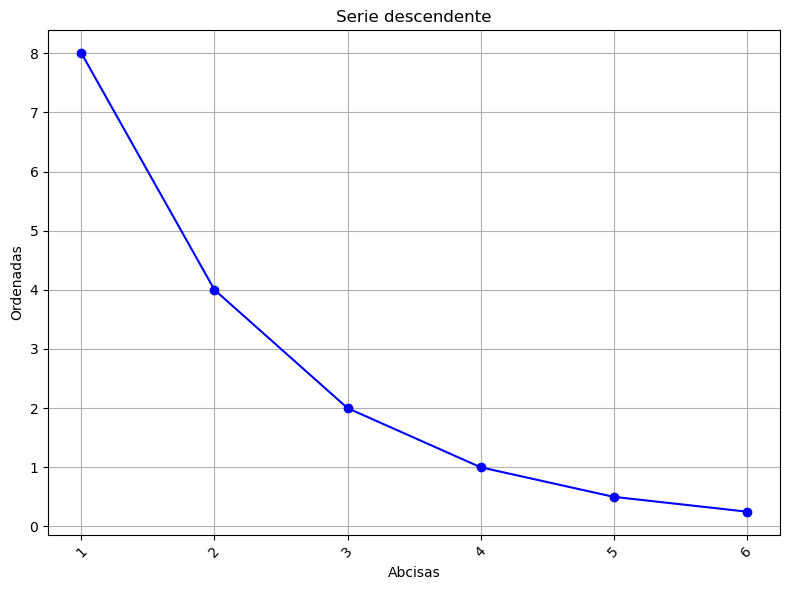

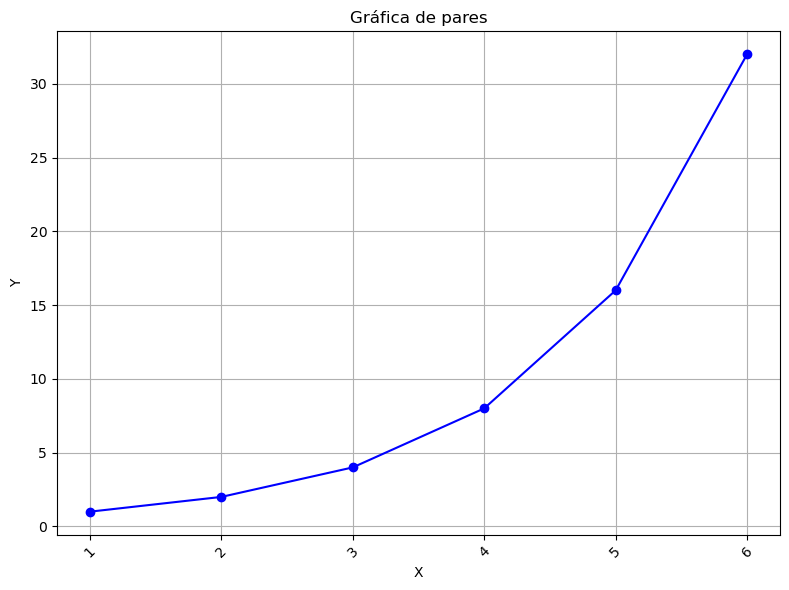

In [53]:
# Pruebas de funcionamiento:

representar_xxx_yyy([(1, 8), (2, 4), (3, 2), (4, 1), (5, 0.5), (6, 0.25)], ["Serie descendente", "Ordenadas", "Abcisas"])

representar_xxx_yyy([(1, 1), (2, 2), (3, 4), (4, 8), (5, 16), (6, 32)])

### Una gráfica concreta

Deseamos representar el número de películas de nuestra base de datos que se han producido en un intervalo de años dado.

In [55]:
# Esta celda debe ser completada por el estudiante
def years_num_movies(dict_data: dict, start_year: int, end_year: int):
    """
    Función que cuenta cuántas películas se han realizado en cada año dentro de un intervalo dado.
    
    Parámetros:
        dict_data := Diccionario con los títulos como claves y los años como valores.
        start_year := Año inicial del intervalo.
        end_year := Año final del intervalo.
    
    Retorna:
        Un diccionario con los años como claves y el número de películas como valores.
    """
    peliculas_por_año = {}

    for titulo, año in dict_data.items():
        try:
            año = int(año)
        except ValueError:
            continue

        if start_year <= año <= end_year:
            if año in peliculas_por_año:
                peliculas_por_año[año] += 1
            else:
                peliculas_por_año[año] = 1

    return peliculas_por_año

def repr_movies_years(dict_data, start_year, end_year):
    """
    Representa el número de películas por año en un intervalo de años dado.

    Parámetros:
        dict_data (dict): Diccionario con los títulos de las películas como claves y los años como valores.
        start_year (int): Año inicial del intervalo (inclusive).
        end_year (int): Año final del intervalo (inclusive).
    
    Notas:
        - La función utiliza `years_num_movies` para obtener el conteo de películas en el intervalo especificado.
        - Se genera un gráfico de barras con `matplotlib`, donde el eje X representa los años y el eje Y representa 
          el número de películas.
        - Las etiquetas del eje X se rotan 45 grados para mejorar la legibilidad.
    """
    # Obtener los datos de películas por año en el intervalo dado
    peliculas_por_año = years_num_movies(dict_data, start_year, end_year)
    
    years = sorted(peliculas_por_año.keys())
    num_movies = [peliculas_por_año[year] for year in years]
    
    # Crear la gráfica
    plt.bar(years, num_movies, color='skyblue')
    
    # Títulos y etiquetas
    plt.title(f'Número de películas entre {start_year} y {end_year}')
    plt.xlabel('Año')
    plt.ylabel('Número de películas')
    
    # Inclinación de las etiquetas en el eje X
    plt.xticks(rotation=45)
    
    # Activar el grid
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Ajustar el diseño para evitar solapamientos
    plt.tight_layout()
    
    # Mostrar la gráfica
    plt.show()


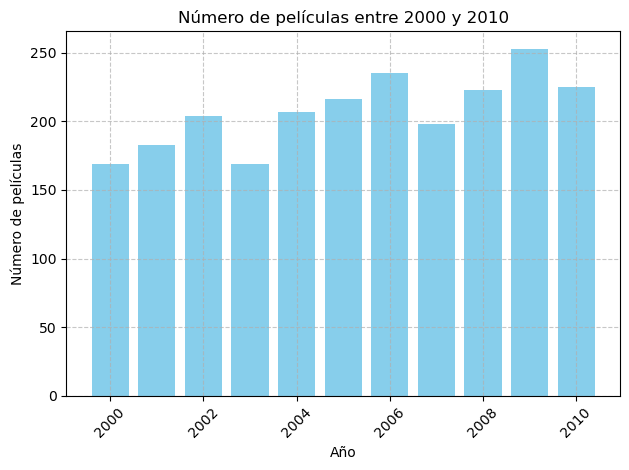

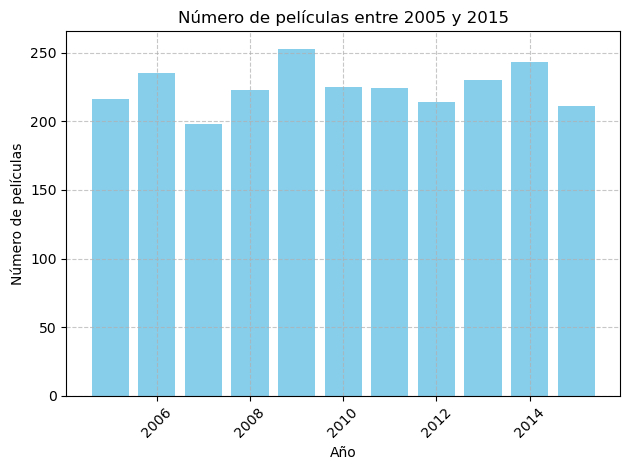

In [56]:
# Test de funcionamiento

repr_movies_years(main_dict_data, 2000, 2010)
repr_movies_years(main_dict_data, 2005, 2015)

# D. Acceso a las urls de imdb y webscraping [2 puntos]

### D.1. Recuperación de las URLs

Con sencillas instrucciones, deseamos recuperar todas las *urls* de las películas de nuestro archivo, mostrando cuántas son, la primera de ellas o las diez primeras por ejemplo:

In [58]:
# Esta celda debe ser completada por el estudiante

# Función para cargar todas las URLs de las películas desde el archivo CSV
def extract_movie_urls(data_file):
    urls = []  # Lista donde se almacenarán las URLs
    
    with open(data_file, mode='r', newline='', encoding='utf-8') as archivo_csv:
        lector_csv = csv.reader(archivo_csv)
        next(lector_csv)  # Saltar la línea de encabezado
        
        for fila in lector_csv:
            if "?ref_" in fila[17]:
                url = fila[17].split("?ref")[0]  # Queda solo la parte antes de ?ref
            urls.append(url)
    
    # Devolver la lista completa de URLs
    return urls
    
urls = extract_movie_urls(MOVIES_DATA)
first_url_movie = urls[0] if urls else "No hay URLs disponibles"  # La primera URL
first_ten_urls = urls[:10]  # Las primeras 10 URLs (si existen)


In [59]:
# Test de funcionamiento

print(len(urls))

print()

print(first_url_movie)

print()

print(first_ten_urls)

5043

http://www.imdb.com/title/tt0499549/

['http://www.imdb.com/title/tt0499549/', 'http://www.imdb.com/title/tt0449088/', 'http://www.imdb.com/title/tt2379713/', 'http://www.imdb.com/title/tt1345836/', 'http://www.imdb.com/title/tt5289954/', 'http://www.imdb.com/title/tt0401729/', 'http://www.imdb.com/title/tt0413300/', 'http://www.imdb.com/title/tt0398286/', 'http://www.imdb.com/title/tt2395427/', 'http://www.imdb.com/title/tt0417741/']


In [60]:
# Una forma de evitar el error "Requests 403 forbidden" al hacer web scraping en las siguientes celdas:

HEADERS = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:98.0) Gecko/20100101 Firefox/98.0",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.5",
        "Accept-Encoding": "gzip, deflate",
        "Connection": "keep-alive",
        "Upgrade-Insecure-Requests": "1",
        "Sec-Fetch-Dest": "document",
        "Sec-Fetch-Mode": "navigate",
        "Sec-Fetch-Site": "none",
        "Sec-Fetch-User": "?1",
        "Cache-Control": "max-age=0",
    }

### D.2. Carga de la estructura sintáctica de una URL

Ahora, deseamos extraer el código `html` de una película.

In [62]:
# Esta celda debe ser completada por el estudiante
import requests
from bs4 import BeautifulSoup

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:98.0) Gecko/20100101 Firefox/98.0",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
    "Accept-Encoding": "gzip, deflate",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
    "Sec-Fetch-Dest": "document",
    "Sec-Fetch-Mode": "navigate",
    "Sec-Fetch-Site": "none",
    "Sec-Fetch-User": "?1",
    "Cache-Control": "max-age=0",
}

def soup_movie(url):
    """
    Extrae el código HTML de una película dada su URL.

    Parámetros:
        url (str): La URL de la película en IMDb.

    Retorna:
        soup: Objeto BeautifulSoup que representa el código HTML de la página.
    """
    try:
        response = requests.get(url, headers=HEADERS)
        response.raise_for_status()  # Lanza un error si la solicitud no es exitosa

        # Analizar el contenido HTML
        soup = BeautifulSoup(response.text, 'html.parser')
        return soup

    except requests.exceptions.RequestException as e:
        print(f"Error al realizar la solicitud: {e}")
        return None

In [63]:
# Test de funcionamiento
soup = soup_movie(first_url_movie)

print(str(soup)[:1000])
print()
print("... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ... ...")
print()
print(str(soup)[-1000:])

<!DOCTYPE html>
<html lang="en-US" xmlns:fb="http://www.facebook.com/2008/fbml" xmlns:og="http://opengraphprotocol.org/schema/"><head><meta charset="utf-8"/><meta content="width=device-width" name="viewport"/><script>if(typeof uet === 'function'){ uet('bb', 'LoadTitle', {wb: 1}); }</script><script>window.addEventListener('load', (event) => {
        if (typeof window.csa !== 'undefined' && typeof window.csa === 'function') {
            var csaLatencyPlugin = window.csa('Content', {
                element: {
                    slotId: 'LoadTitle',
                    type: 'service-call'
                }
            });
            csaLatencyPlugin('mark', 'clickToBodyBegin', 1730206562974);
        }
    })</script><title>Avatar (2009) - IMDb</title><meta content="Avatar: Directed by James Cameron. With Sam Worthington, Zoe Saldana, Sigourney Weaver, Stephen Lang. A paraplegic Marine dispatched to the moon Pandora on a unique mission becomes torn between following his orders and pr

### D.3. Extracción de algunas piezas de información de una URL

Y ahora, con dicho código, deseamos extraer la siguiente información, referida a la película `first_url_movie`:

- La etiqueta completa del título de la película
- La descripción (sólo el contenido).
- La lista de los actores del *reparto principal*
- La información sobre el presupuesto

In [65]:
# Esta celda debe ser completada por el estudiante
def extract_movie_info(url):
    """
    Extrae información de la película desde la URL dada.

    Parámetros:
        url (str): La URL de la película en IMDb.

    Retorna:
        dict: Información de la película.
    """
    soup = soup_movie(url)
    if not soup:
        return None

    movie_info = {}

    # Extraer el título de la película
    title_tag = soup.find('h1')
    if title_tag:
        movie_info['title'] = title_tag.text.strip()

    # Extraer la descripción de la película
    description_tag = soup.find('div', class_='summary_text')
    if description_tag:
        movie_info['description'] = description_tag.text.strip()

    # Extraer la lista de actores del reparto principal
    actors_tags = soup.find_all('a', class_='sc-16z54d8-1 fZyZxu')
    actors = [actor.text.strip() for actor in actors_tags]
    movie_info['actors'] = actors

    # Extraer el presupuesto
    budget_tag = soup.find('div', string='Budget:')
    if budget_tag:
        # El siguiente elemento después de "Budget:" contiene el valor
        budget_value = budget_tag.find_next_sibling().text.strip()
        movie_info['budget'] = budget_value

    return movie_info

# Test de funcionamiento
movie_info = extract_movie_info(first_url_movie)

if movie_info:
    print("Título:", movie_info.get('title'))
    print("Descripción:", movie_info.get('description'))
    print("Reparto Principal:", movie_info.get('actors'))
    print("Presupuesto:", movie_info.get('budget'))


Título: Avatar
Descripción: None
Reparto Principal: []
Presupuesto: None


### D.4. Actores que intervienen en una lista de URLs

Necesitamos crear un archivo con los actores del reparto principal de las películas de IMDB, dada la lista de sus URLs.

In [67]:
# Esta celda debe ser completada por el estudiante
import re  # Importa la biblioteca de expresiones regulares

def gather_actors(filename, urls):
    """
    Extrae actores del reparto principal de las películas a partir de una lista de URLs y los guarda en un archivo.

    Parámetros:
        filename (str): Nombre del archivo donde se guardarán los actores.
        urls (list): Lista de URLs de las películas.
    """
    with open(filename, 'w', encoding='utf-8') as file:
        for url in urls:
            soup = soup_movie(url)
            if not soup:
                continue
            
            # Encontrar la etiqueta <meta> con la descripción
            meta_tag = soup.find('meta', attrs={'name': 'description'})
            if not meta_tag:
                file.write(f"URL: {url}\n")
                file.write("No se encontraron actores.\n\n")
                continue
            
            # Obtener el contenido de la descripción
            description = meta_tag['content']
            # print(f"URL: {url}\nDescripción encontrada: {description}")
        
            # Utilizar expresión regular para extraer los actores
            # Utilizar expresión regular para extraer los actores
            match = re.search(r'With (.+?)\.', description)  # Ajustada
            if match:
                # Obtener los actores, separando por comas y limpiando espacios
                actors = match.group(1).split(', ')
                actors = [actor.strip() for actor in actors]
            
                # Guardar los actores en el archivo
                file.write(f"URL: {url}\n")
                file.write("Actores:\n")
                file.write(", ".join(actors) + "\n\n")

            else:
                file.write(f"URL: {url}\n")
                file.write("No se encontraron actores en la descripción.\n\n")         



In [68]:
# Test de funcionamiento

# OJO: esta operación puede llevar bastante tiempo.
# Para esta prueba, usamos un número limitado de películas.

gather_actors("actors_3_first_movies.txt", urls[:3])

! type actors_3_first_movies.txt

URL: http://www.imdb.com/title/tt0499549/
Actores:
Sam Worthington, Zoe Saldana, Sigourney Weaver, Stephen Lang

URL: http://www.imdb.com/title/tt0449088/
Actores:
Johnny Depp, Geoffrey Rush, Orlando Bloom, Keira Knightley

URL: http://www.imdb.com/title/tt2379713/
Actores:
Daniel Craig, Christoph Waltz, LÃ©a Seydoux, Ralph Fiennes



In [69]:
# La siguente llamada llevaría un tiempo realmente largo:

# import time # para cronometrar esta función, que tarda mucho

# reloj_inicio = time.time()
# gather_actors("actors_all_movies.txt", urls)
# reloj_fin = time.time()

# print("Tiempo invertido: %s segundos." % (reloj_fin - reloj_inicio))

# E. Pandas [2 puntos]

### E.1. El primer paso es la carga del archivo en un dataframe

In [71]:
# Esta celda debe ser completada por el estudiante
import pandas as pd

def load_dataframe(filepath):
    """
    Carga el archivo en un DataFrame de pandas.

    Parámetros:
        filepath (str): Ruta al archivo.

    Retorna:
        DataFrame: Contiene los datos del archivo.
    """
    
    # Carga el archivo en un DataFrame, ajustando el delimitador si es necesario
    return pd.read_csv(filepath, delimiter=',', encoding='utf-8')


In [72]:
# Test de funcionamiento

tabla_completa = load_dataframe(MOVIES_DATA)

tabla_completa

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,NaN,Comedy|Drama,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,841.0,NaN,Crime|Drama|Mystery|Thriller,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,NaN,Drama|Horror|Thriller,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Comedy|Drama|Romance,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660


### E.2. Tabla de los campos principales

A pertir de la tabla anterior, construimos otra con sólo algumos de los campos:

In [74]:
# Esta celda debe ser completada por el estudiante
def fields_selected_dataframe(dataframe):
    """
    Filtra las columnas seleccionadas del DataFrame original.

    Parámetros:
        dataframe (DataFrame): DataFrame original.

    Retorna:
        DataFrame: Un nuevo DataFrame con las columnas seleccionadas.
    """
    # Columnas que deseamos conservar
    selected_columns = [
        'movie_title', 'title_year', 'director_name', 'actor_1_name',  
        'language', 'country', 'color', 'budget', 'imdb_score', 
        'movie_imdb_link'
    ]
    
    return dataframe[selected_columns]


In [75]:
# test de comprobación

tabla_breve = fields_selected_dataframe(tabla_completa)

tabla_breve

,movie_title,title_year,director_name,actor_1_name,language,country,color,budget,imdb_score,movie_imdb_link
0,Avatar,2009.0,James Cameron,CCH Pounder,English,USA,Color,237000000.0,7.9,http://www.imdb.com/title/tt0499549/?ref_=fn_t...
1,Pirates of the Caribbean: At World's End,2007.0,Gore Verbinski,Johnny Depp,English,USA,Color,300000000.0,7.1,http://www.imdb.com/title/tt0449088/?ref_=fn_t...
2,Spectre,2015.0,Sam Mendes,Christoph Waltz,English,UK,Color,245000000.0,6.8,http://www.imdb.com/title/tt2379713/?ref_=fn_t...
3,The Dark Knight Rises,2012.0,Christopher Nolan,Tom Hardy,English,USA,Color,250000000.0,8.5,http://www.imdb.com/title/tt1345836/?ref_=fn_t...
4,Star Wars: Episode VII - The Force Awakens ...,NaN,Doug Walker,Doug Walker,NaN,NaN,NaN,NaN,7.1,http://www.imdb.com/title/tt5289954/?ref_=fn_t...
...,...,...,...,...,...,...,...,...,...,...
5038,Signed Sealed Delivered,2013.0,Scott Smith,Eric Mabius,English,Canada,Color,NaN,7.7,http://www.imdb.com/title/tt3000844/?ref_=fn_t...
5039,The Following,NaN,NaN,Natalie Zea,English,USA,Color,NaN,7.5,http://www.imdb.com/title/tt2071645/?ref_=fn_t...
5040,A Plague So Pleasant,2013.0,Benjamin Roberds,Eva Boehnke,English,USA,Color,1400.0,6.3,http://www.imdb.com/title/tt2107644/?ref_=fn_t...
5041,Shanghai Calling,2012.0,Daniel Hsia,Alan Ruck,English,USA,Color,NaN,6.3,http://www.imdb.com/title/tt2070597/?ref_=fn_t...


### E.3. Columnas de una tabla

¿Cuáles son las columnas de nuestrsa `tabla_breve`?

In [77]:
# Esta celda debe ser completada por el estudiante
print("Las columnas de nuestra tabla breve son: \n", tabla_breve.columns)


Las columnas de nuestra tabla breve son: 
 Index(['movie_title', 'title_year', 'director_name', 'actor_1_name',
       'language', 'country', 'color', 'budget', 'imdb_score',
       'movie_imdb_link'],
      dtype='object')


### E.4. Campos missing

Algunos campos muestran un valod `NaN`. Deseamos cambiarlo por una cadena de caracteres: `"Desc"`.

In [79]:
# Esta celda debe ser completada por el estudiante
tabla_breve = tabla_breve.fillna("Desc")


In [80]:
# Test de comprobación

tabla_breve

,movie_title,title_year,director_name,actor_1_name,language,country,color,budget,imdb_score,movie_imdb_link
0,Avatar,2009.0,James Cameron,CCH Pounder,English,USA,Color,237000000.0,7.9,http://www.imdb.com/title/tt0499549/?ref_=fn_t...
1,Pirates of the Caribbean: At World's End,2007.0,Gore Verbinski,Johnny Depp,English,USA,Color,300000000.0,7.1,http://www.imdb.com/title/tt0449088/?ref_=fn_t...
2,Spectre,2015.0,Sam Mendes,Christoph Waltz,English,UK,Color,245000000.0,6.8,http://www.imdb.com/title/tt2379713/?ref_=fn_t...
3,The Dark Knight Rises,2012.0,Christopher Nolan,Tom Hardy,English,USA,Color,250000000.0,8.5,http://www.imdb.com/title/tt1345836/?ref_=fn_t...
4,Star Wars: Episode VII - The Force Awakens ...,Desc,Doug Walker,Doug Walker,Desc,Desc,Desc,Desc,7.1,http://www.imdb.com/title/tt5289954/?ref_=fn_t...
...,...,...,...,...,...,...,...,...,...,...
5038,Signed Sealed Delivered,2013.0,Scott Smith,Eric Mabius,English,Canada,Color,Desc,7.7,http://www.imdb.com/title/tt3000844/?ref_=fn_t...
5039,The Following,Desc,Desc,Natalie Zea,English,USA,Color,Desc,7.5,http://www.imdb.com/title/tt2071645/?ref_=fn_t...
5040,A Plague So Pleasant,2013.0,Benjamin Roberds,Eva Boehnke,English,USA,Color,1400.0,6.3,http://www.imdb.com/title/tt2107644/?ref_=fn_t...
5041,Shanghai Calling,2012.0,Daniel Hsia,Alan Ruck,English,USA,Color,Desc,6.3,http://www.imdb.com/title/tt2070597/?ref_=fn_t...


### E.5. Director $\rightarrow$ películas y número de películas

Función que averigua la lista de títulos de películas de un director dado:

In [83]:
# Esta celda debe ser completada por el estudiante

def titulos_de_director_df(dataframe, director_name):
    """
    Filtra las películas de un director específico y devuelve un DataFrame con esos títulos, limpiando caracteres especiales.

    Parámetros:
        dataframe (DataFrame): DataFrame que contiene los datos de las películas.
        director_name (str): Nombre del director para filtrar.

    Retorna:
        DataFrame: DataFrame con las películas del director especificado.
    """
    # Filtrar las filas donde el nombre del director coincida
    director_movies = dataframe[dataframe["director_name"] == director_name].copy()
    
    # Limpiar el texto en la columna de títulos
    director_movies.loc[:, "movie_title"] = director_movies["movie_title"].str.normalize('NFKC').str.strip()
    
    return director_movies[["movie_title"]]



In [84]:
# Test de comprobación:

tabla_tits = titulos_de_director_df(tabla_breve, "James Cameron")
tabla_tits

,movie_title
0,Avatar
26,Titanic
288,Terminator 2: Judgment Day
291,True Lies
606,The Abyss
2486,Aliens
3575,The Terminator


In [85]:
list_tits = tabla_tits["movie_title"].to_list()
print(list_tits)

['Avatar', 'Titanic', 'Terminator 2: Judgment Day', 'True Lies', 'The Abyss', 'Aliens', 'The Terminator']


Deseamos saber qué directores han dirigido el máximo número de películas, junto con ese número de películas.

In [87]:
# Esta celda debe ser completada por el estudiante

def directors_max_movies_df(dataframe):
    """
    Identifica los directores que han dirigido el mayor número de películas y devuelve
    sus nombres junto con el número de películas.

    Parámetros:
        dataframe (DataFrame): DataFrame que contiene los datos de las películas.

    Retorna:
        DataFrame: Un DataFrame con los directores que han dirigido el mayor número de películas
                   y el conteo de esas películas.
    """
    # Filtrar los directores que no son 'Desc'
    filtered_dataframe = dataframe[dataframe['director_name'] != 'Desc']
    # Contar el número de películas por director
    director_counts = filtered_dataframe.groupby("director_name").size().reset_index(name='movie_count')
    
    # Obtener el número máximo de películas
    max_movies = director_counts["movie_count"].max()
    
    # Filtrar los directores que tienen el máximo número de películas
    max_directors = director_counts[director_counts["movie_count"] == max_movies]
    
    return max_directors


In [88]:
# test de comprobación:

directors_max_movies_df(tabla_breve)

,director_name,movie_count
2157,Steven Spielberg,26


# Parte F. Un cálculo masivo con map-reduce [0,5 puntos]

En este apartado se ha de realizar un programa aparte, *basado en la técnica de map-reduce*, que calcule, para cada idioma, en qué países en que se han producido películas y la suma de los presupuestos de dichas películas. Cuando el idioma o el país o el presupuesto no se conozcan, no se considerará esta película.

    C:\...> python language_budget_countries.py -q algunos_campos.txt

El programa funcionará necesariamente con la técnica map-reduce, que podemos poner en juego con la librería `mrjob`.

El funcionamiento del mismo se puede activar también desde aquí:

In [90]:
# Hagamos una llamada al programa de consola desde aquí:
! python language_budget_countries.py -q algunos_campos.txt

["Aboriginal","Australia"]	6000000.0
["Aboriginal","UK"]	80000000.0
["Arabic","Egypt"]	1500000.0
["Arabic","France"]	1300000.0
["Arabic","Turkey"]	8300000.0
["Arabic","United Arab Emirates"]	125000.0
["Aramaic","USA"]	30000000.0
["Bosnian","USA"]	13000000.0
["Cantonese","China"]	25000000.0
["Cantonese","Hong Kong"]	129500000.0
["Chinese","China"]	12000000.0
["Czech","Czech Republic"]	84450000.0
["Danish","Denmark"]	50100000.0
["Dari","Afghanistan"]	46000.0
["Dari","USA"]	20000000.0
["Dutch","Netherlands"]	32150000.0
["Dzongkha","Australia"]	1800000.0
["English","Aruba"]	35000000.0
["English","Australia"]	1550805523.0
["English","Bahamas"]	5000000.0
["English","Belgium"]	49000000.0
["English","Brazil"]	3000000.0
["English","Bulgaria"]	7000000.0
["English","Canada"]	1562632000.0
["English","Chile"]	26000000.0
["English","China"]	287005000.0
["English","Czech Republic"]	62000000.0
["English","Denmark"]	75200000.0
["English","France"]	2960460000.0
["English","Georgia"]	20000000.0
["English

In [91]:
# Para que el resultado se almacene en un archivo:
! python language_budget_countries.py -q algunos_campos.txt > language_countries_budgets.txt

La siguiente celda me permite ver tu programa cómodamente desde aquí.

In [93]:
def print_file(filename):
    with open(filename, "r") as f:
        for line in f:
            print(line, end="")

            
print_file("language_countries_budgets.txt")

["Aboriginal","Australia"]	6000000.0
["Aboriginal","UK"]	80000000.0
["Arabic","Egypt"]	1500000.0
["Arabic","France"]	1300000.0
["Arabic","Turkey"]	8300000.0
["Arabic","United Arab Emirates"]	125000.0
["Aramaic","USA"]	30000000.0
["Bosnian","USA"]	13000000.0
["Cantonese","China"]	25000000.0
["Cantonese","Hong Kong"]	129500000.0
["Chinese","China"]	12000000.0
["Czech","Czech Republic"]	84450000.0
["Danish","Denmark"]	50100000.0
["Dari","Afghanistan"]	46000.0
["Dari","USA"]	20000000.0
["Dutch","Netherlands"]	32150000.0
["Dzongkha","Australia"]	1800000.0
["English","Aruba"]	35000000.0
["English","Australia"]	1550805523.0
["English","Bahamas"]	5000000.0
["English","Belgium"]	49000000.0
["English","Brazil"]	3000000.0
["English","Bulgaria"]	7000000.0
["English","Canada"]	1562632000.0
["English","Chile"]	26000000.0
["English","China"]	287005000.0
["English","Czech Republic"]	62000000.0
["English","Denmark"]	75200000.0
["English","France"]	2960460000.0
["English","Georgia"]	20000000.0
["English

# Parte G. Un apartado libre [0.5 puntos]

<br>

<font color="darkblue">
El objetivo de este proyecto es analizar los presupuestos de películas a partir de un archivo de datos en formato de texto delimitado por '|'. Se busca responder a las siguientes preguntas:

Para ello se parte del archivo generado con mapreduce del apartado anterior "language_countries_budgets.txt"

¿Cuál es el idioma con el presupuesto total más alto y en qué país se produce la mayoría de las películas en ese idioma?
¿Cómo se distribuyen los presupuestos de las películas por idioma en un gráfico?
¿Existen diferencias significativas en los presupuestos entre los países que producen películas en un mismo idioma?
Para llevar a cabo este análisis, utilizaremos la librería Pandas para el manejo de datos y Seaborn para la visualización gráfica. Se presentarán los resultados en un informe que incluye gráficos que ilustren los hallazgos de manera clara y atractiva.
</font>

<br>

In [95]:
# Este apartado debe ser completado por el estudiante
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

def analizar_presupuestos(file_path):
    """
    Analiza los presupuestos de películas por idioma y país desde un archivo de texto.

    Esta función lee un archivo que contiene datos de presupuesto organizados por idioma y país,
    calcula el presupuesto total por idioma, identifica el idioma con el presupuesto más alto,
    y visualiza los resultados a través de gráficos de barras.

    Parámetros:
    -----------
    file_path : str
        La ruta del archivo de texto que contiene los datos de idioma, país y presupuesto.
        El archivo debe tener un formato donde cada línea contiene una lista de idioma y país
        seguido del presupuesto, separado por tabulaciones.

    Salida:
    -------
    - Imprime un resumen con el idioma que tiene el mayor presupuesto.
    - Muestra un gráfico de barras que representa la distribución de presupuestos por idioma.
    - Muestra un gráfico de barras que representa la distribución de presupuestos por país
      para el idioma con el mayor presupuesto.

    Ejemplo de uso:
    ---------------
    >>> analizar_presupuestos('ruta/al/archivo/language_countries_budgets.txt')
    """
    # Creamos listas para almacenar los datos
    idiomas = []
    paises = []
    presupuestos = []

    # Leemos el archivo línea por línea
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')# Separar los datos en idioma, país y presupuesto
            
            if len(parts) == 2:  # Asegúrate de que hay dos partes (idioma y presupuesto)
                idioma_pais = ast.literal_eval(parts[0])  # Convierte el string a tupla
                presupuesto = float(parts[1])  # Presupuesto como número
                
                # Añadimos los datos a las listas
                idiomas.append(idioma_pais[0])  # Idioma
                paises.append(idioma_pais[1])   # País
                presupuestos.append(presupuesto) # Presupuesto
    
    df = pd.DataFrame({   # Creamos el DataFrame
        'Idioma': idiomas,
        'País': paises,
        'Presupuesto': presupuestos})

    
    print(df.head())  # Mostramos las primeras filas del DataFrame

    # Idioma con el Presupuesto Total Más Alto
    presupuesto_por_idioma = df.groupby('Idioma')['Presupuesto'].sum().reset_index()
    idioma_max = presupuesto_por_idioma.loc[presupuesto_por_idioma['Presupuesto'].idxmax()]

    print(f"Idioma con mayor presupuesto: {idioma_max['Idioma']} con un total de {idioma_max['Presupuesto']}")

    # Distribución de Presupuestos por Idioma
    plt.figure(figsize=(10, 6))
    sns.barplot(data=presupuesto_por_idioma, x='Idioma', y='Presupuesto', color='blue')  # Cambiamos palette a color
    plt.title('Distribución de Presupuestos por Idioma')
    plt.xlabel('Idioma')
    plt.ylabel('Presupuesto Total')
    plt.xticks(rotation=60, ha='right', fontsize=10)  # Rotar las etiquetas del eje x más y ajustarlas a la derecha plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Presupuestos por País en el Idioma con Mayor Presupuesto
    df_idioma_max = df[df['Idioma'] == idioma_max['Idioma']]
    presupuesto_por_pais = df_idioma_max.groupby('País')['Presupuesto'].sum().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=presupuesto_por_pais, x='País', y='Presupuesto', color='orange')  # Cambiamos palette a color
    plt.title(f'Distribución de Presupuestos por País')
    plt.xlabel('País')
    plt.ylabel('Presupuesto Total')
    plt.xticks(rotation=60, ha='right', fontsize=10)  # Rotar las etiquetas del eje x más y ajustarlas a la derecha plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


       Idioma       País  Presupuesto
0  Aboriginal  Australia    6000000.0
1  Aboriginal         UK   80000000.0
2      Arabic      Egypt    1500000.0
3      Arabic     France    1300000.0
4      Arabic     Turkey    8300000.0
Idioma con mayor presupuesto: English con un total de 148634092778.0


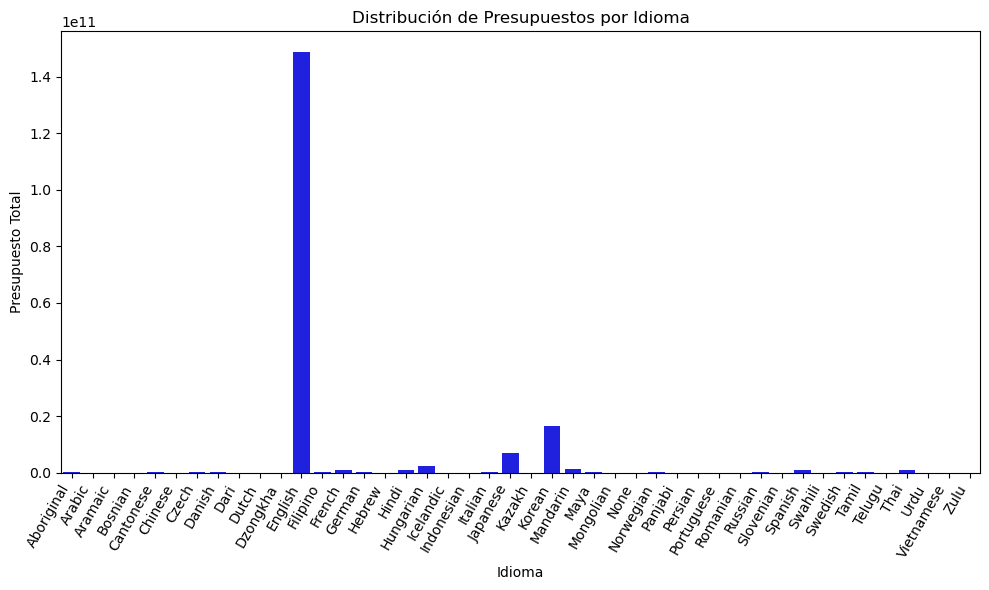

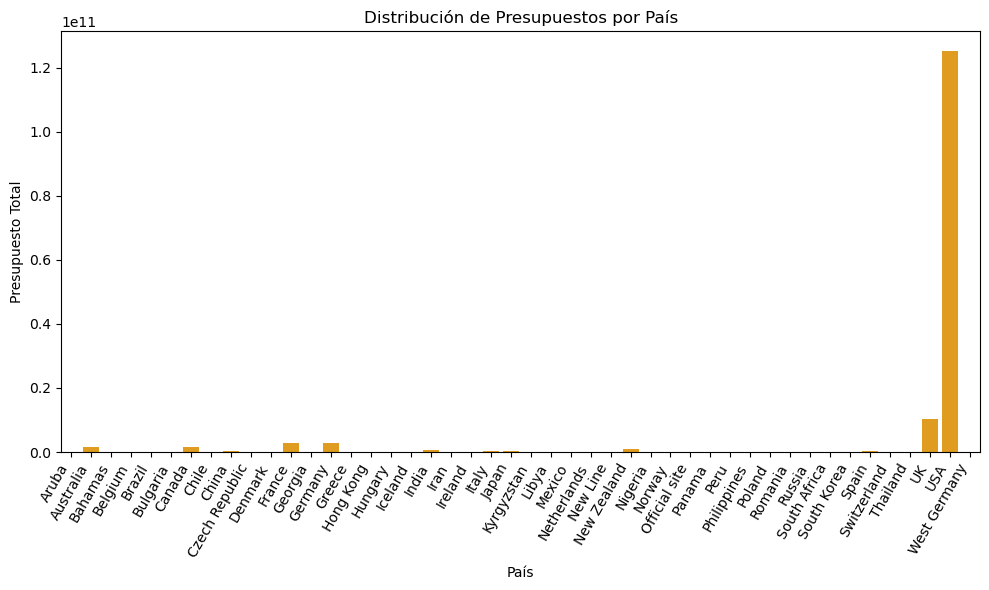

In [96]:
# Pruebas de funcionamiento, también tarea del estudiante:
analizar_presupuestos("language_countries_budgets.txt")


##### Datos personales

<br>

<font color="darkblue">

-   **Apellidos:** GASPAR PIQUERO
-   **Nombre:** MIGUEL
-   **Email:** miguelgasparpiquero@gmail.com
-   **Fecha:** 29/10/2024

<br>

<font color="black">
    
### Ficha de autoevaluación

<br>


<br>

<font color="darkblue">
    
|Apartado|Calificación|Comentario|
|-|-|-|
|a)  |2.5  / 2.5  |Completamente resuelto |
|b)  |2.0  / 2.0  |Completamente resuelto |
|c)  |1.5  / 1.5  |Completamente resuelto |
|d)  |1.0 / 1.0  |Completamente resuelto |
|e)  |2.0  / 2.0  |Completamente resuelto |
|f)  |0.5  / 0.5  |Completamente resuelto |
|g)  |0.5  / 0.5  |Completamente resuelto |
|**Total** |**10.0** / 10.0|**Sobresaliente**|
</font>

<br>

<font color="black">
   
### Ayuda recibida y fuentes utilizadas
    
</font>

<br>

<font color="darkblue">
A lo largo del desarrollo de este proyecto, he utilizado diversas fuentes para enriquecer mi comprensión del análisis de datos. En particular, el conjunto de datos proviene de Kaggle, donde se puede encontrar información detallada sobre las películas de IMDB. Además, he consultado documentación de Python y la biblioteca Seaborn para profundizar en las técnicas de visualización gráfica. La interacción con la comunidad en foros y plataformas de programación también ha sido valiosa para resolver dudas y mejorar mis enfoques.
</font>

<br>

<font color="black">

    
### Comentario adicional
</font>
<br>
<font color="darkblue">
Este proyecto ha sido una gran oportunidad para aplicar y consolidar mis conocimientos en programación y análisis de datos. Estoy satisfecho con los resultados y con el aprendizaje adquirido a lo largo del proceso.
<br>

In [98]:
# Esta celda se ha de respetar: está aquí para comprobar
# el funcionamiento de algunas funciones por parte de tu profesor
